# Лабораторная работа: Спайковые нейронные сети

# Теоретическая часть

## 1. Суть нейроморфных вычислений и спайковых нейронных сетей

Нейроморфные вычисления — это парадигма, направленная на создание вычислительных систем, архитектура и принципы работы которых вдохновлены биологическим мозгом. В отличие от классических нейронных сетей, которые оперируют непрерывными значениями активаций (например, вещественными числами), спайковые нейронные сети (Spiking Neural Networks, SNN) используют **дискретные события во времени** — спайки (или потенциалы действия).

Основная цель нейроморфных систем — достичь высокой **энергоэффективности** и способности эффективно обрабатывать **временно́зависимые данные** (аудио, видео, сенсорные потоки), что критически важно для задач встраиваемого ИИ, робототехники и интерфейсов мозг-компьютер.


## 2. Модель нейрона LIF (Leaky Integrate-and-Fire)

Модель LIF является одной из самых распространенных и вычислительно эффективных моделей спайкового нейрона. Она описывает динамику мембранного потенциала $V(t)$.

Уравнение мембранного потенциала:

$$
\tau_m \frac{dV(t)}{dt} = -(V(t) - V_{rest}) + R_m I(t)
$$

где:
- $V(t)$ — мембранный потенциал в момент времени $t$,
- $\tau_m = R_m C_m$ — постоянная времени мембраны (произведение сопротивления $R_m$ и емкости $C_m$),
- $V_{rest}$ — потенциал покоя,
- $R_m$ — мембранное сопротивление,
- $I(t)$ — суммарный входной ток (от синапсов).

При достижении порогового потенциала $V_{th}$ нейрон генерирует спайк, и его потенциал сбрасывается до потенциала покоя $V_{rest}$ на период рефрактерности $\tau_{ref}$:

$$
\text{if } V(t) \geq V_{th} \text{, then:} \\
V(t) \rightarrow V_{rest} \\
\text{Запрет на срабатывание на время } \tau_{ref}
$$

## 3. Спайк-тайм-зависимая пластичность (STDP)

STDP — это биоинспирированное правило обучения, которое модифицирует силу синаптической связи (вес $w$) на основе временной корреляции между спайками пресинаптического и постсинаптического нейронов.

Формально, изменение веса $\Delta w$ определяется так:

$$
\Delta w =
\begin{cases}
A_{+} \cdot \exp\left(-\frac{\Delta t}{\tau_{+}}\right), & \text{если } \Delta t > 0 \text{ (пре-спайк до пост-спайка)} \\
-A_{-} \cdot \exp\left(-\frac{|\Delta t|}{\tau_{-}}\right), & \text{если } \Delta t < 0 \text{ (пре-спайк после пост-спайка)}
\end{cases}
$$

где:
- $\Delta t = t_{post} - t_{pre}$ — разница во времени между постсинаптическим и пресинаптическим спайками,
- $A_{+}, A_{-}$ — амплитуды усиления и ослабления связи,
- $\tau_{+}, \tau_{-}$ — временные константы для потенциации и депрессии.

STDP реализует принцип Хебба: *"Neurons that fire together, wire together"* (Нейроны, которые возбуждаются вместе, связываются вместе).

## Практическая часть

В данной работе вам предлагается реализовать и исследовать простую спайковую нейронную сеть на основе модели LIF с обучением по правилу STDP. Вы должны:

1.  Реализовать модель LIF-нейрона и исследовать его отклик на различные входные токи.
2.  Создать сеть из нескольких LIF-нейронов (например, входной слой, скрытый слой) и визуализировать распространение спайковой активности.
3.  Реализовать правило обучения STDP для синаптических связей.
4.  Обучить сеть на простой задаче (например, ассоциации паттернов) или классификации простых спайковых последовательностей.
5.  Проанализировать динамику весов, итоговую активность сети и эффективность обучения.

In [2243]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple
from sklearn.model_selection import train_test_split

In [2244]:
# Определение параметров нейрона LIF
@dataclass
class LIFNeuron:
    tau_m: float = 20.0    # Постоянная времени мембраны (мс)
    v_rest: float = -70.0  # Потенциал покоя (мВ)
    v_thresh: float = -55.0 # Пороговый потенциал (мВ)
    v_reset: float = -75.0 # Потенциал сброса (мВ)
    r_m: float = 10.0      # Мембранное сопротивление (МОм)
    tau_ref: float = 4.0   # Рефрактерный период (мс)

    def __post_init__(self):
        self.v = self.v_rest
        self.refractory_until = 0
        self.spike_times = []
        self.spike = False
        self.v_trace = []

    def step(self, I_inj: float, dt: float, t: float) -> bool:
        """Один шаг интегрирования. Возвращает True, если был спайк."""
        self.spike = False
        # Проверка рефрактерности
        if t < self.refractory_until:
            self.v = self.v_reset

            self.v_trace.append(self.v)

            return False

        # Интегрирование уравнения LIF (простая Эйлерова схема)
        dv = (-(self.v - self.v_rest) + self.r_m * I_inj) / self.tau_m
        self.v += dv * dt

        # Проверка на срабатывание
        if self.v >= self.v_thresh:
            self.v = self.v_reset
            self.refractory_until = t + self.tau_ref
            self.spike_times.append(t)

            # self.v_trace.append(self.v)
            self.spike = True
            # return True
        
        self.v_trace.append(self.v)
        return self.spike

In [2245]:
class SNNNetwork:
    def init_weights(n_inputs, n_outputs, set=True, normal=False, A=1.0, mu=0.0, sigma=1):
        if set:
            weights = [[A for j in range(n_outputs)] for i in range(n_inputs)]
        elif normal:
            weights = [[np.random.normal(loc=mu, scale=sigma) * A for j in range(n_outputs)] for i in range(n_inputs)]
        else:
            weights = [[np.random.random() * A for j in range(n_outputs)] for i in range(n_inputs)]
        return weights
    
    def __init__(self, n_inputs, n_outputs, t_range, I_inj, weights, dt=0.1, A_p=1, A_m=1, tau_p=1, tau_m=1):
        # связей: n_inputs * n_outputs
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs

        self.dt = dt
        self.t_range = t_range
        self.I_inj = I_inj  # t_range * n_inputs
        self.weights = weights
        self.weight_history = [[[] for j in range(n_outputs)] for i in range(n_inputs)]
        self.A_p = A_p
        self.A_m = A_m
        self.tau_p = tau_p
        self.tau_m = tau_m
        self.inputs = [LIFNeuron() for i in range(n_inputs)]
        self.outputs = [LIFNeuron() for j in range(n_outputs)]

    def _update_weights(self, t):
        for i, input in enumerate(self.inputs):
            for j, output in enumerate(self.outputs):
                last_spike_in = input.spike_times[-1] if len(input.spike_times) else -float('inf')
                last_spike_out = output.spike_times[-1] if len(output.spike_times) else -float('inf')
                spike_dif = last_spike_out - last_spike_in
                dw = 0
                if (not np.isfinite(spike_dif)) or spike_dif == 0:
                    # self.weight_history[i, j].append(self.weights[i, j])
                    self.weight_history[i][j].append(self.weights[i][j])
                    continue
                # spike_dif = np.clip([spike_dif], -3000, 3000)[0]
                if spike_dif > 0:
                    ex = - spike_dif / self.tau_p
                    ex = np.clip([ex], -500, 0)[0]
                    dw = self.A_p * np.exp(ex)
                else:
                    ex = spike_dif / self.tau_m
                    ex = np.clip([ex], -500, 0)[0]
                    dw = - self.A_m * np.exp(ex)
                self.weights[i][j] += dw
                self.weights[i][j] = np.clip([self.weights[i][j]], 0, None)[0]
                self.weight_history[i][j].append(self.weights[i][j])

    def simulate(self):

        # print('W', np.shape(self.weights))
        # print('I_inj', np.shape(self.I_inj))
        # print('T', np.shape(self.t_range))
        # print('WH', np.shape(self.weight_history))

        for k, t in enumerate(self.t_range):
            for i, input in enumerate(self.inputs):
                # I_in = self.I_inj[k, i]
                I_in = self.I_inj[i][k]
                input.step(I_in, self.dt, t)

            for j, output in enumerate(self.outputs):
                # v_in = sum(self.weights[i, j] * (1.0 if self.inputs[i].spike else 0.0) for i in range(self.n_inputs))
                # v_in = 0
                # for i, input in enumerate(self.inputs):
                #     if input.spike:
                #         v_in += self.weights[i][j]
                #         print(f'Output {j} received a spike from input {i}, weight={self.weights[i][j]}, v_in={v_in}')
                v_in = sum(self.weights[i][j] * (1.0 if self.inputs[i].spike else 0.0) for i in range(self.n_inputs))
                output.step(v_in, self.dt, t)

            self._update_weights(t)

In [2246]:
# Функция для визуализации потенциала и спайков
def plot_neuron_activity(t_range: np.ndarray, v_trace: List[float], spike_times: List[float], label='', top=False, top_label='', top_func=[]):
    fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(10, 4), sharex=True, gridspec_kw={'height_ratios': [2, 4, 1]})
    if top:
        ax0.plot(t_range, top_func, 'b-', label=top_label)
        ax0.set_ylabel(top_label)
        ax0.set_title(top_label)
        ax0.grid(True)
    else:
        plt.delaxes(ax0)
        # fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4), sharex=True, gridspec_kw={'height_ratios': [4, 1]})

    ax1.plot(t_range, v_trace, 'b-', label='Мембранный потенциал')
    ax1.axhline(y=LIFNeuron.v_thresh, color='r', linestyle='--', label='Порог')
    ax1.axhline(y=LIFNeuron.v_rest, color='g', linestyle='--', label='Покой')
    ax1.axhline(y=LIFNeuron.v_reset, color='y', linestyle='--', label='Ресет')
    ax1.set_ylabel('Потенциал (мВ)')
    ax1.set_title(label)
    ax1.legend()
    ax1.grid(True)

    ax2.eventplot(spike_times, colors='k', linewidths=2)
        
    ax2.set_xlabel('Время (мс)')
    ax2.set_ylabel('Спайки')
    ax2.set_yticks([])
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [2247]:
def timeplot(t_range, arr, label='', height=3):
    fig = plt.figure(figsize=(10, height))
    plt.plot(t_range, arr, 'b', label=label)
    plt.title(label)
    plt.ylabel(label)
    # plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [2248]:
def get_I_from_type(t_range, type: str, A = 1, f = 1, b = 0.0):
    I_inj = np.zeros_like(t_range)
    if type == 'sin':
        mult = 2 * np.pi * f / len(t_range)
        for i, t in enumerate(t_range):
            I_inj[i] = A * (np.sin(i * mult - np.pi / 2 + b * 2 * np.pi) + 1) / 2
    elif type == 'step':
        period = len(t_range) / (f)
        for i, t in enumerate(t_range):
            phase = (i + b * period) % period / period
            I_inj[i] = A if phase >= 0.5 else 0.0
    elif type == 'triangle':
        period = len(t_range) / (f)
        for i, t in enumerate(t_range):
            phase = (i + b * period) % period / period
            I_inj[i] = 2 * A * phase if phase < 0.5 else 2 * A * (1 - phase)
    return I_inj

Входы
Вход 1


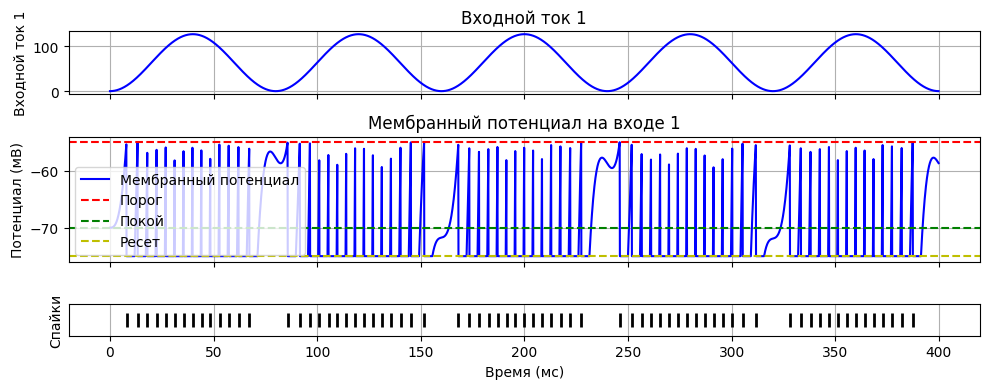

Вход 2


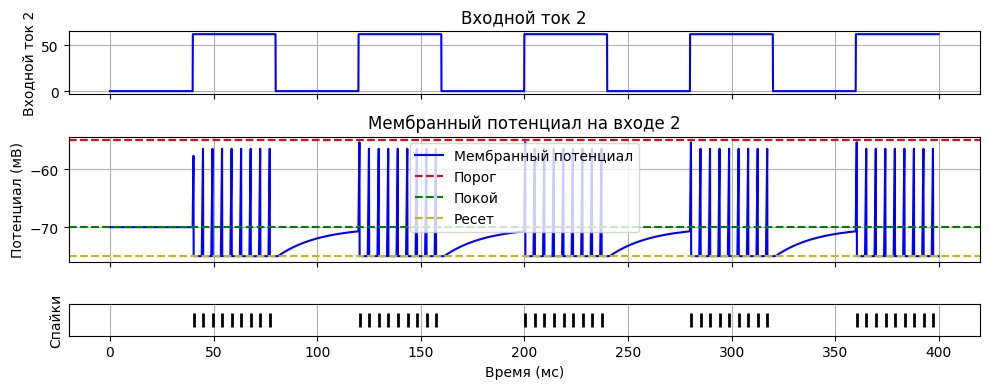

Вход 3


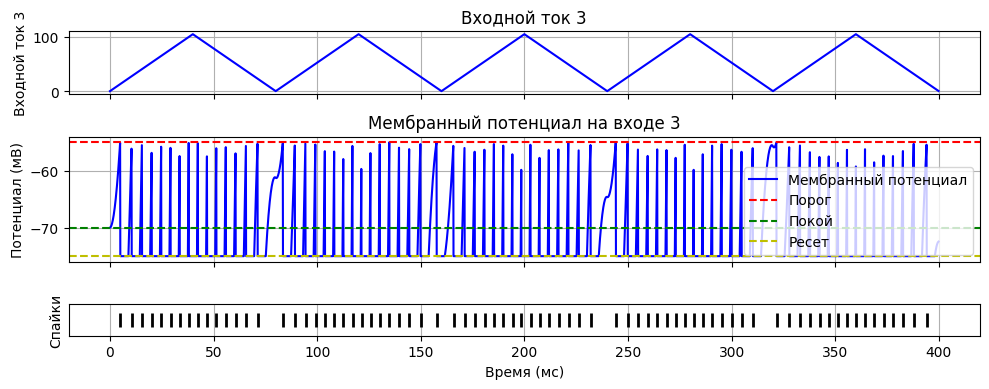

Выходы
Выход 1


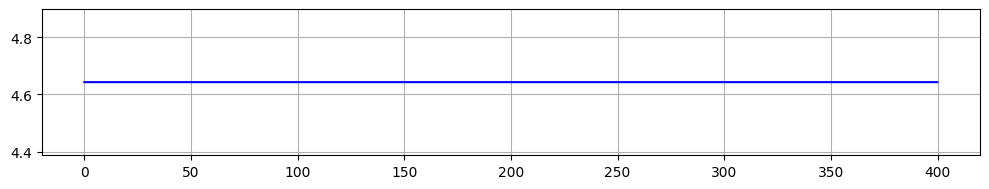

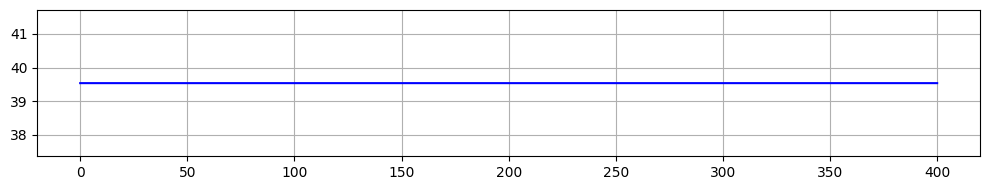

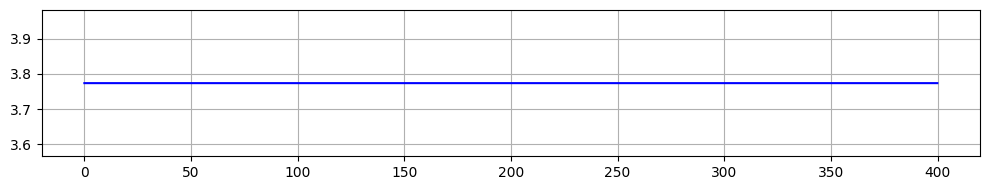

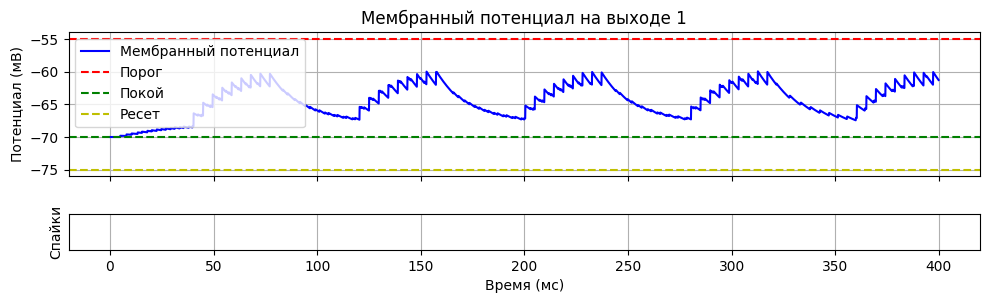

In [2249]:
# Пример использования: ответ на постоянный ток
if __name__ == "__main__":
    dval = 0.1
    T = 400

    t_range = np.arange(0, T, dval)
    # I_inj = np.zeros_like(t_range)
    # I_inj[(t_range > 50) & (t_range < 150)] = 3.0  # nA

    n_inputs = 3
    n_outputs = 1

    I_inj = []

    f=5
    # for i in range(n_inputs):
    #     signal = np.random.choice(['sin', 'step', 'triangle'])
    #     I_inj.append(get_I_from_type(t_range, signal, A=np.random.randint(50,151), f=f))

    types = ['sin', 'step', 'triangle']
    for i in range(n_inputs):
        signal = types[i % 3]
        I_inj.append(get_I_from_type(t_range, signal, A=np.random.randint(50,151), f=f))

    weights = SNNNetwork.init_weights(n_inputs, n_outputs, set=False, normal=False, A=50)#, normal=False, A=150)

    model = SNNNetwork(n_inputs, n_outputs, t_range, I_inj, weights, dval)

    # model.T = T
    model.A_p = 0.02
    model.A_m = 0.02 * 1.1
    model.tau_p = 0.01
    model.tau_m = 0.02

    model.simulate()

    print('Входы')
    for i, input in enumerate(model.inputs):
        print(f'Вход {i + 1}')
        plot_neuron_activity(t_range, input.v_trace, input.spike_times, f'Мембранный потенциал на входе {i + 1}',
                             top=True, top_label=f'Входной ток {i + 1}', top_func=I_inj[i])
    print('Выходы')
    for j, output in enumerate(model.outputs):
        print(f'Выход {j + 1}')
        for i in range(n_inputs):
            timeplot(t_range, model.weight_history[i][j], height=2)
        plot_neuron_activity(t_range, output.v_trace, output.spike_times, f'Мембранный потенциал на выходе {j + 1}')

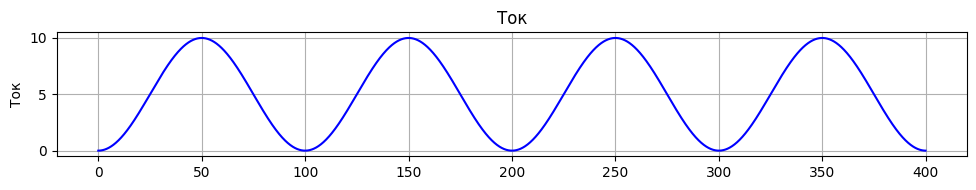

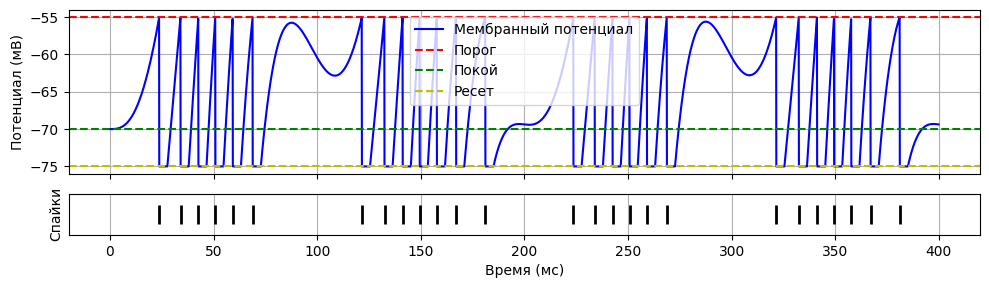

Количество спайков: 26


In [2250]:
neu = LIFNeuron()

I = get_I_from_type(t_range, 'sin', A=10, f=4)

v_trace = []
spike_times = []

for i, t in enumerate(t_range):
    neu.step(I[i], dval, t)

# Визуализация
timeplot(t_range, I, 'Ток', 2)
plot_neuron_activity(t_range, neu.v_trace, neu.spike_times)
print(f"Количество спайков: {len(neu.spike_times)}")

In [2251]:
# n_inputs = 2
# n_outputs = 2
# A_p = 0.01
# A_m = 0.01
# tau_p = 20
# tau_m = 20

# n_sec = 100
# pause = 20
# n_samples = 50
# T = (n_sec + pause) * n_samples
# dt = 1
# t_range = np.arange(0, T, dt)

# I_inj = [np.zeros_like(t_range) for i in range(n_inputs)]
# mask = np.repeat(np.arange(0, n_inputs), (n_samples // n_inputs))[:len(t_range)]

# np.random.shuffle(mask)
# for i, _ in enumerate(t_range):
#     sample = i // (n_sec + pause)
#     if i % (n_sec + pause) == 0:
#         end = min(i + n_sec, len(t_range))
#         I_inj[mask[sample]][i:end] = 20

In [2252]:
def class_steps(t_range, n_inputs, n_samples, n_sec, pause, A=20):
    I_inj = [np.zeros_like(t_range) for i in range(n_inputs)]
    mask = np.repeat(np.arange(0, n_inputs), (n_samples // n_inputs))[:len(t_range)]

    np.random.shuffle(mask)
    for i, _ in enumerate(t_range):
        sample = i // (n_sec + pause)
        if i % (n_sec + pause) == 0:
            end = min(i + n_sec, len(t_range))
            I_inj[mask[sample]][i:end] = A
    return I_inj, mask

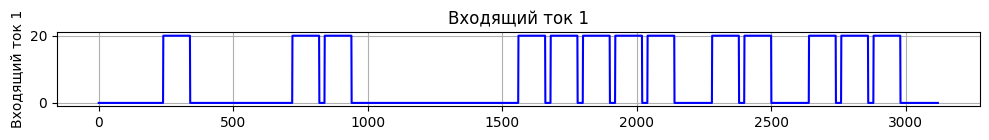

Пиков: 13.0


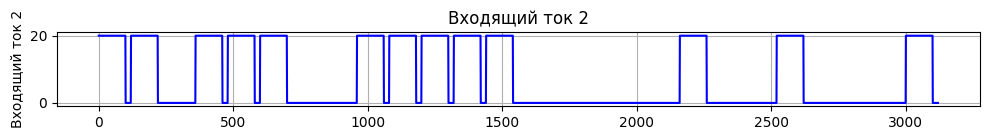

Пиков: 13.0


In [2253]:
n_inputs = 2
n_outputs = 2
A_p = 0.01
A_m = 0.01
tau_p = 20
tau_m = 20

n_sec = 100
pause = 20
n_samples = 26
T = (n_sec + pause) * n_samples
dt = 1
t_range = np.arange(0, T, dt)

I_inj, true_labels = class_steps(t_range, n_inputs, n_samples, n_sec, pause, A=20)

for i in range(n_inputs):
    timeplot(t_range, I_inj[i], f'Входящий ток {i + 1}', height=1.5)
    print(f'Пиков: {len(I_inj[i].nonzero()[0]) / n_sec}')

In [2254]:
# np.random.seed(42)
# weights = SNNNetwork.init_weights(n_inputs, n_outputs, set=False, normal=False, A=40)
# weights = SNNNetwork.init_weights(n_inputs, n_outputs, set=False, normal=True, A=5, mu=5)
# weights = SNNNetwork.init_weights(n_inputs, n_outputs, set=True, A=5)

weights = [           # не убирать
    [40.0, 0.0],
    [0.0, 40.0]
]

print(f'Начальные веса:')
display(weights)

model = SNNNetwork(n_inputs, n_outputs, t_range, I_inj, weights, dt, A_p=A_p, A_m=A_m, tau_p=tau_p, tau_m=tau_m)
model.simulate()

Начальные веса:


[[40.0, 0.0], [0.0, 40.0]]

Входы
Вход 1:


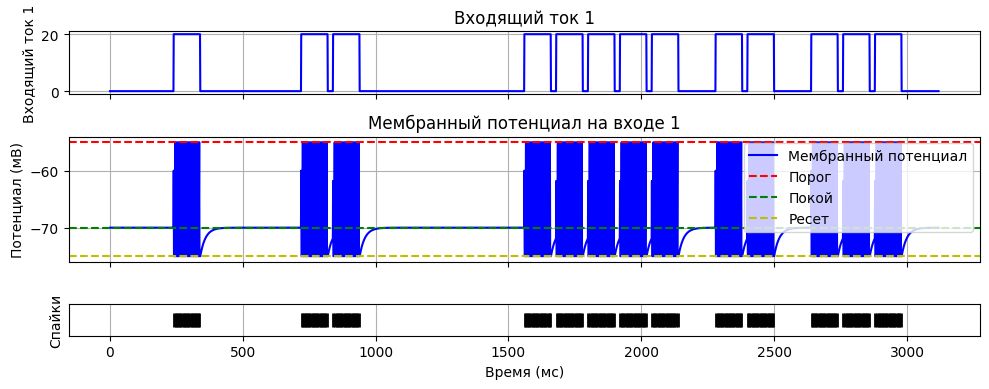

Спайков: 221 (17.0 спайков/образец)
Вход 2:


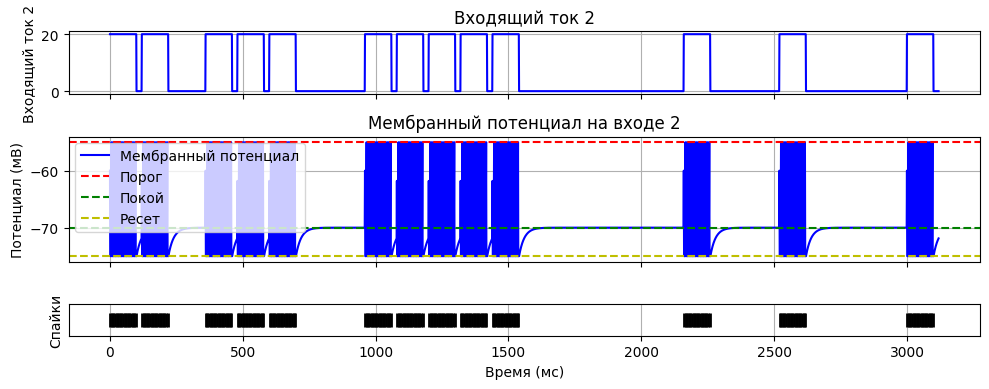

Спайков: 221 (17.0 спайков/образец)
Выходы
Выход 1


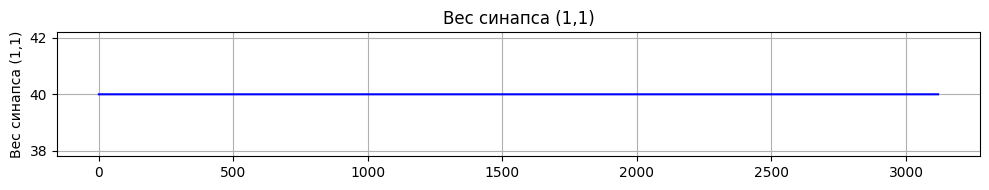

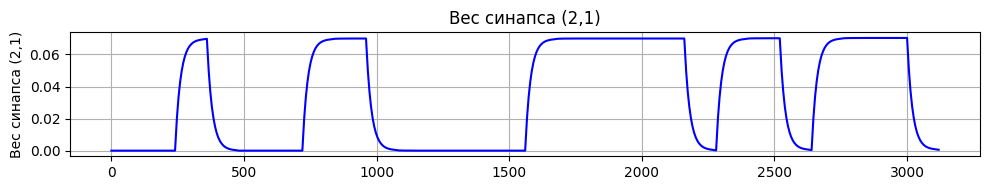

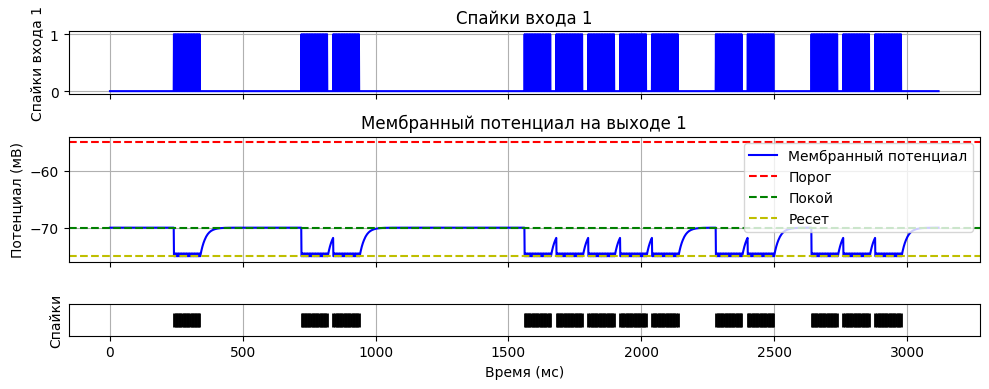

Спайков: 221
Выход 2


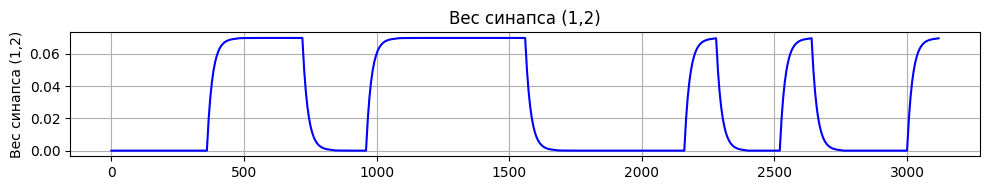

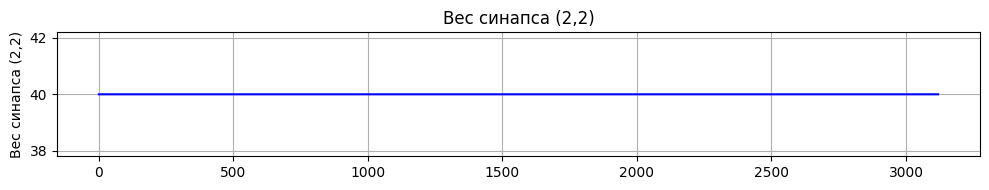

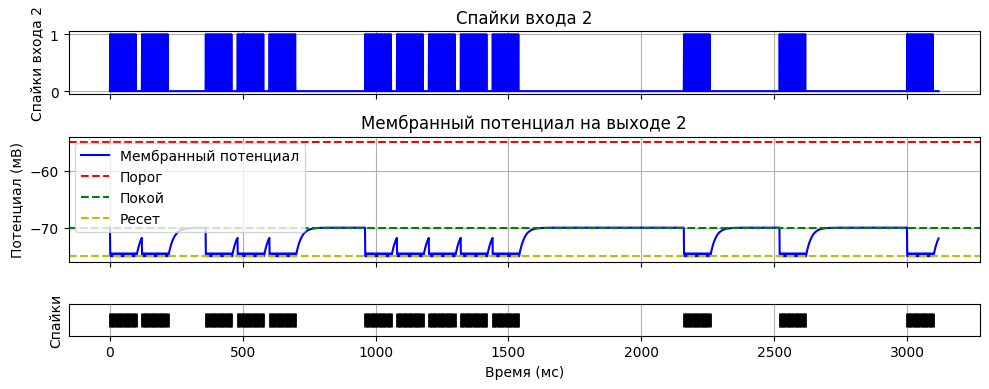

Спайков: 221


In [2255]:
print('Входы')
for i, input in enumerate(model.inputs):
    print(f'Вход {i + 1}:')
    plot_neuron_activity(
        model.t_range, input.v_trace, input.spike_times, f'Мембранный потенциал на входе {i + 1}',
        top=True, top_label=f'Входящий ток {i + 1}', top_func=I_inj[i]
        )
    print(f'Спайков: {len(input.spike_times)} ({len(input.spike_times) / (n_samples // n_inputs)} спайков/образец)')
print('Выходы')
for j, output in enumerate(model.outputs):
    print(f'Выход {j + 1}')
    for i in range(n_inputs):
        timeplot(model.t_range, model.weight_history[i][j], height=2, label=f'Вес синапса ({i + 1},{j + 1})')
    plot_neuron_activity(
        model.t_range, output.v_trace, output.spike_times, f'Мембранный потенциал на выходе {j + 1}',
        top=True, top_label=f'Спайки входа {j + 1}', top_func=[1.0 if t in model.inputs[j].spike_times else 0.0 for i, t in enumerate(t_range)]
        )
    print(f'Спайков: {len(output.spike_times)}')

In [2256]:
def spike_accuracy(y_true, model: SNNNetwork, n_samples, n_sec, pause):
    # print(y_true)
    pred_labels = np.zeros(n_samples, dtype=int)

    for sample in range(n_samples):
        t_start = sample * (n_sec + pause)
        t_end = t_start + n_sec

        spike_counts = []
        for j, output in enumerate(model.outputs):
            spike_times = np.array(output.spike_times)
            count = np.sum((spike_times >= t_start) & (spike_times < t_end))
            spike_counts.append(count)
        # print('SP', spike_counts)
        if np.any(spike_counts):
            pred_labels[sample] = np.argmax(spike_counts)
        else:
            pred_labels[sample] = -1
    # print(pred_labels)

    accuracy = np.mean(pred_labels == true_labels)
    rev_pred = [1 if pred_labels[i] == 0
                else 
                0 if pred_labels[i] == 1
                else -1
                for i in range(len(pred_labels))]
    rev_acc = np.mean(rev_pred == true_labels)
    # print(rev_pred)
    # print(f"Точность: {max(accuracy, rev_acc):.4f}")
    return max(accuracy, rev_acc)

In [2257]:
print(f"Точность: {spike_accuracy(true_labels, model, n_samples, n_sec, pause):.4f}")

Точность: 1.0000


In [2258]:
# для нижних (тесты распределений)
n_inputs = 2
n_outputs = 2
A_p = 0.01
A_m = 0.01
tau_p = 20
tau_m = 20

n_sec = 100
pause = 20
n_samples = 50
T = (n_sec + pause) * n_samples
dt = 1

In [2259]:
t_range = np.arange(0, T, dt)
kstr = 10
best_weights_d = []
best_acc_d = 0
av_acc_d = 0
best_model_d = None

for k in range(kstr):
    I_inj, true_labels = class_steps(t_range, n_inputs, n_samples, n_sec, pause, A=20)

    # np.random.seed(42)
    weights = SNNNetwork.init_weights(n_inputs, n_outputs, set=False, normal=False, A=40)

    # print(f'Начальные веса:')
    # display(weights)

    start_w = np.copy(weights)

    model = SNNNetwork(n_inputs, n_outputs, t_range, I_inj, weights, dt, A_p=A_p, A_m=A_m, tau_p=tau_p, tau_m=tau_m)
    model.simulate()

    acc = spike_accuracy(true_labels, model, n_samples, n_sec, pause)
    av_acc_d += acc
    if acc > best_acc_d:
        best_acc_d = acc
        best_weights_d = np.copy(start_w)
        best_model_d = model
    # print(f'Начальные веса: {np.round(np.ravel(start_w), 4)}, точность: {acc:.4f}')

av_acc_d /= kstr
print(f'Лучшие веса: {np.round(np.ravel(best_weights_d), 4)}, лучшая точность: {best_acc_d:.4f}, средняя точность (макро) {av_acc_d:.4f}')

Лучшие веса: [36.812  17.9656 21.4572 29.6837], лучшая точность: 0.9800, средняя точность (макро) 0.6540


In [2260]:
t_range = np.arange(0, T, dt)
kstr = 10
best_weights_n = []
best_acc_n = 0
av_acc_n = 0
best_model_n = None

for k in range(kstr):
    I_inj, true_labels = class_steps(t_range, n_inputs, n_samples, n_sec, pause, A=20)

    # np.random.seed(42)
    weights = SNNNetwork.init_weights(n_inputs, n_outputs, set=False, normal=True, A=40, mu=0, sigma=1)
    # display(weights)
    for i in range(len(weights)):
        for j in range(len(weights[i])):
            weights[i][j] = abs(weights[i][j])
    # display(weights)
    # print(f'Начальные веса:')
    # display(weights)

    start_w = np.copy(weights)

    model = SNNNetwork(n_inputs, n_outputs, t_range, I_inj, weights, dt, A_p=A_p, A_m=A_m, tau_p=tau_p, tau_m=tau_m)
    model.simulate()

    acc = spike_accuracy(true_labels, model, n_samples, n_sec, pause)
    av_acc_n += acc
    if acc > best_acc_n:
        best_acc_n = acc
        best_weights_n = np.copy(start_w)
        best_model_n = model
    # print(f'Начальные веса: {np.round(np.ravel(start_w), 4)}, точность: {acc:.4f}')

av_acc_n /= kstr
print(f'Лучшие веса: {np.round(np.ravel(best_weights_n), 4)}, лучшая точность: {best_acc_n:.4f}, средняя точность (макро) {av_acc_n:.4f}')

Лучшие веса: [59.1065  6.6096  9.6432 93.4392], лучшая точность: 1.0000, средняя точность (макро) 0.7180


In [2261]:
def cont_mat(y_true, model: SNNNetwork, n_samples, n_sec, pause):
    # print(y_true)
    y_pred = np.zeros(n_samples, dtype=int)
    cont_mat = [   
        #-1 0  1  y_true
        [0, 0, 0],  # -1    y_pred
        [0, 0, 0],  # 0
        [0, 0, 0]   # 1
    ]
    for sample in range(n_samples):
        t_start = sample * (n_sec + pause)
        t_end = t_start + n_sec

        spike_counts = []
        for j, output in enumerate(model.outputs):
            spike_times = np.array(output.spike_times)
            count = np.sum((spike_times >= t_start) & (spike_times < t_end))
            spike_counts.append(count)
        # print('SP', spike_counts)
        if np.any(spike_counts):
            y_pred[sample] = np.argmax(spike_counts)
        else:
            y_pred[sample] = -1

        cont_mat[y_pred[sample] + 1][y_true[sample] + 1] += 1
    return cont_mat

In [2262]:
I_inj, true_labels = class_steps(t_range, n_inputs, n_samples, n_sec, pause, A=20)

# np.random.seed(42)
weights = SNNNetwork.init_weights(n_inputs, n_outputs, set=False, normal=False, A=40)

print(f'Начальные веса:')
display(weights)

model = SNNNetwork(n_inputs, n_outputs, t_range, I_inj, weights, dt, A_p=A_p, A_m=A_m, tau_p=tau_p, tau_m=tau_m)
model.simulate()

acc = spike_accuracy(true_labels, model, n_samples, n_sec, pause)

mat = cont_mat(true_labels, model, n_samples, n_sec, pause)

print(f'Точность (макро): {acc:.4f}')


mat_df = pd.DataFrame(mat, columns=['Miss', 'True 0', 'True 1'])


display(mat_df)
mc = sum(mat[0])
tp = mat[1][1]
tn = mat[2][2]
fp = mat[1][2]
fn = mat[2][1]
calc_acc = (tp + tn) / (tp + tn + fp + fn + mc)
print(f'Рассчитанная точность: {calc_acc:.4f}')

Начальные веса:


[[30.31248127568464, 14.467632452010118],
 [29.528672005452794, 16.06980821699914]]

Точность (макро): 0.5000


,Miss,True 0,True 1
0,0,0,0
1,0,25,25
2,0,0,0


Рассчитанная точность: 0.5000
